In [ ]:
# for numerical computing
import numpy as np
# for dataframes
import pandas as pd
# for easier visualization
import seaborn as sns
# for visualization and to display plots
from matplotlib import pyplot as plt
%matplotlib inline
# import color maps
from matplotlib.colors import ListedColormap
# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")
from math import sqrt
# to split train and test set
from sklearn.model_selection import train_test_split
# to perform hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score
#import xgboost
import os


In [ ]:
from google.colab import files
df = files.upload()

Saving employee_data.csv to employee_data.csv


In [ ]:
import io
import pandas as pd
df = pd.read_csv(io.BytesIO(uploaded['employee_data.csv']))
# Dataset is now stored in a Pandas Dataframe

In [ ]:
# Dataframe dimensions
df.shape

(14249, 10)

In [ ]:
df.columns

Index(['avg_monthly_hrs', 'department', 'filed_complaint', 'last_evaluation',
       'n_projects', 'recently_promoted', 'salary', 'satisfaction', 'status',
       'tenure'],
      dtype='object')

In [ ]:
df.head()

,avg_monthly_hrs,department,filed_complaint,last_evaluation,n_projects,recently_promoted,salary,satisfaction,status,tenure
0,221,engineering,NaN,0.932868,4,NaN,low,0.829896,Left,5.0
1,232,support,NaN,NaN,3,NaN,low,0.834544,Employed,2.0
2,184,sales,NaN,0.788830,3,NaN,medium,0.834988,Employed,3.0
3,206,sales,NaN,0.575688,4,NaN,low,0.424764,Employed,2.0
4,249,sales,NaN,0.845217,3,NaN,low,0.779043,Employed,3.0


In [ ]:
df.describe()

,avg_monthly_hrs,filed_complaint,last_evaluation,n_projects,recently_promoted,satisfaction,tenure
count,14249.000000,2058.0,12717.000000,14249.000000,300.0,14068.000000,14068.000000
mean,199.795775,1.0,0.718477,3.773809,1.0,0.621295,3.497228
std,50.998714,0.0,0.173062,1.253126,0.0,0.250469,1.460917
min,49.000000,1.0,0.316175,1.000000,1.0,0.040058,2.000000
25%,155.000000,1.0,0.563866,3.000000,1.0,0.450390,3.000000
50%,199.000000,1.0,0.724939,4.000000,1.0,0.652527,3.000000
75%,245.000000,1.0,0.871358,5.000000,1.0,0.824951,4.000000
max,310.000000,1.0,1.000000,7.000000,1.0,1.000000,10.000000


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fde9af20690>,
      dtype=object)

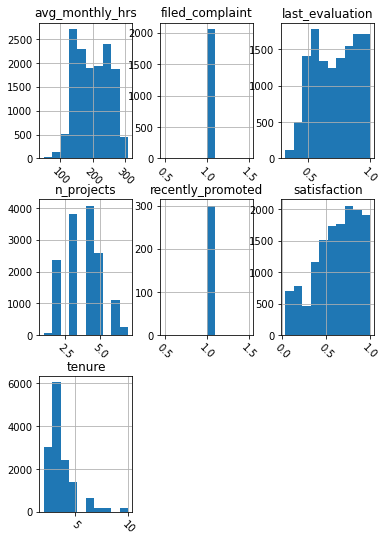

In [ ]:
# Plot histogram grid
df.hist(figsize=(6,9), xrot=-45)

In [ ]:
# Summarize categorical features
df.describe(include=['object'])

,department,salary,status
count,13540,14249,14249
unique,12,3,2
top,sales,low,Employed
freq,3923,6952,10857


In [ ]:
df['department'].value_counts()

sales                     3923
engineering               2592
support                   2122
IT                        1161
product                    860
marketing                  819
finance                    728
management                 595
information_technology     209
temp                       181
admin                      176
procurement                174
Name: department, dtype: int64

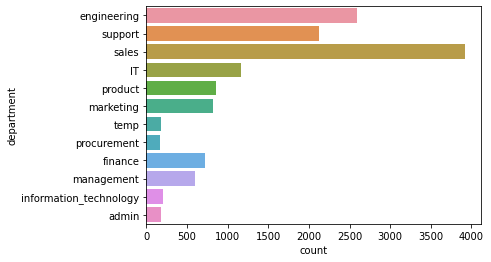

In [ ]:
## We can also use bar plots instead
plt.figure(figsize=(6,4))
sns.countplot(y='department', data=df)

In [ ]:
df['salary'].value_counts()

low       6952
medium    6146
high      1151
Name: salary, dtype: int64

In [ ]:
df['status'].value_counts()

Employed    10857
Left         3392
Name: status, dtype: int64

In [ ]:
## Segmentations

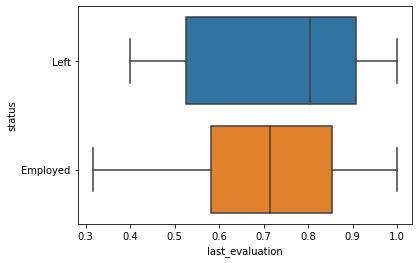

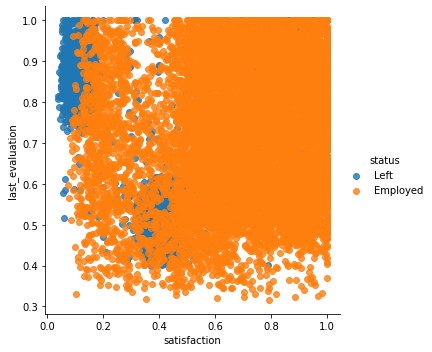

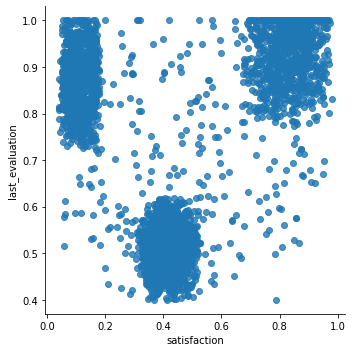

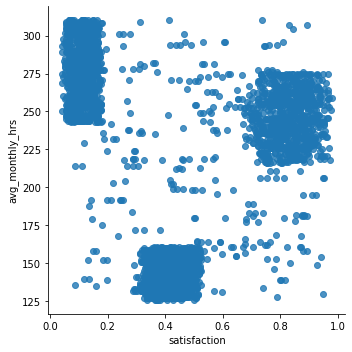

In [ ]:
## status vs last_evaluation
sns.boxplot(y='status', x='last_evaluation', data=df)
# Scatterplot of satisfaction vs. last_evaluation
sns.lmplot(x='satisfaction', y='last_evaluation', hue='status', data=df, fit_reg=False)
# Scatterplot of satisfaction vs. last_evaluation, only those who have left
sns.lmplot(x='satisfaction', y='last_evaluation', data=df[df.status == 'Left'], fit_reg=False)
# Scatterplot of satisfaction vs. avg_monthly_hrs, only those who have left
sns.lmplot(x='satisfaction', y='avg_monthly_hrs', data=df[df.status == 'Left'], fit_reg=False)

(14221, 10)
(14068, 10)


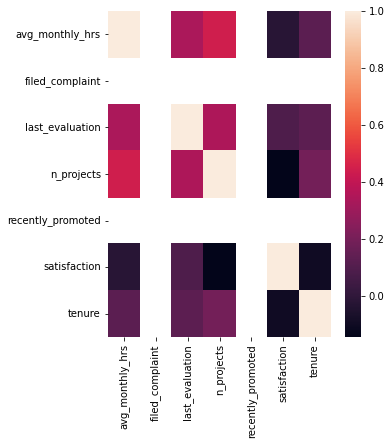

In [ ]:
#Correlations
df.corr()
plt.figure(figsize=(5,6))
sns.heatmap(df.corr())
# Drop duplicates
df = df.drop_duplicates()
print(df.shape)
# Drop temporary workers
df = df[df.department != 'temp']
print(df.shape)

[nan  1.]
[nan  1.]
[0. 1.]
[0. 1.]


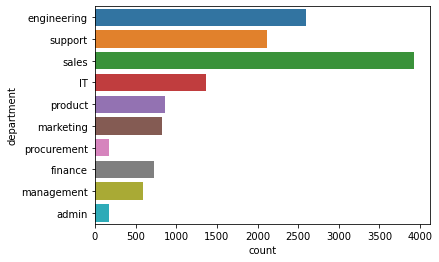

In [ ]:
#Fix structural errors
# Print unique values of 'filed_complaint'
print( df.filed_complaint.unique() )
# Print unique values of 'recently_promoted'
print( df.recently_promoted.unique() )
# Missing filed_complaint values should be 0
df['filed_complaint'] = df.filed_complaint.fillna(0)
# Missing recently_promoted values should be 0
df['recently_promoted'] = df.recently_promoted.fillna(0)
# Print unique values of 'filed_complaint'
print( df.filed_complaint.unique() )
# Print unique values of 'recently_promoted'
print( df.recently_promoted.unique() )
# 'information_technology' should be 'IT'
df.department.replace('information_technology', 'IT', inplace=True)
# Plot class distributions for 'department'
sns.countplot(y='department', data=df)


In [ ]:
#Outliers
# Display number of missing values by feature
df.isnull().sum()

avg_monthly_hrs            0
department                 0
filed_complaint            0
last_evaluation            0
n_projects                 0
recently_promoted          0
salary                     0
satisfaction               0
status                     0
tenure                     0
last_evaluation_missing    0
dtype: int64

In [ ]:
#Fill missing values in department with 'Missing'
# Equivalent to adding a new class
df['department'].fillna('Missing', inplace=True)
# Indicator variable for missing last_evaluation
df['last_evaluation_missing'] = df.last_evaluation.isnull().astype(int)
# Fill missing values in last_evaluation with 0
df.last_evaluation.fillna(0, inplace=True)
# Display number of missing values by feature
df.isnull().sum()

avg_monthly_hrs            0
department                 0
filed_complaint            0
last_evaluation            0
n_projects                 0
recently_promoted          0
salary                     0
satisfaction               0
status                     0
tenure                     0
last_evaluation_missing    0
dtype: int64

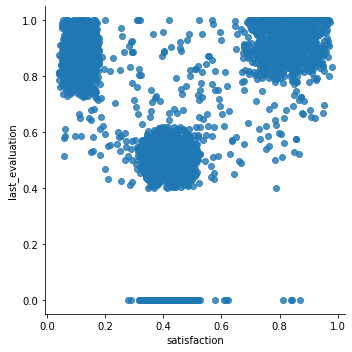

In [ ]:
# Scatterplot of satisfaction vs. last_evaluation, only those who have left
sns.lmplot(x='satisfaction', y='last_evaluation', data=df[df.status == 'Left'], fit_reg=False)

In [ ]:
# Create indicator features
df['underperformer'] = ((df.last_evaluation < 0.6) &
                        (df.last_evaluation_missing == 0)).astype(int)

df['unhappy'] = (df.satisfaction < 0.2).astype(int)

df['overachiever'] = ((df.last_evaluation > 0.8) & (df.satisfaction > 0.7)).astype(int)
# The proportion of observations belonging to each group
df[['underperformer', 'unhappy', 'overachiever']].mean()

underperformer    0.381291
unhappy           0.092195
overachiever      0.177069
dtype: float64